## Generate NPT Figure

### Attention

### Attention Rollout

In [1]:
import numpy as np

data = np.load("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/negative/negative_curves/attention_rollout/02F4A1FB_left_curve.npy", allow_pickle=True).item()

percentages = np.array(data["percentages"])
confidences = np.array(data["confidences"])

print(percentages.shape, confidences.shape)

(21,) (21,)


#### Overall

curves shape: (116, 21)
percentages shape: (21,)


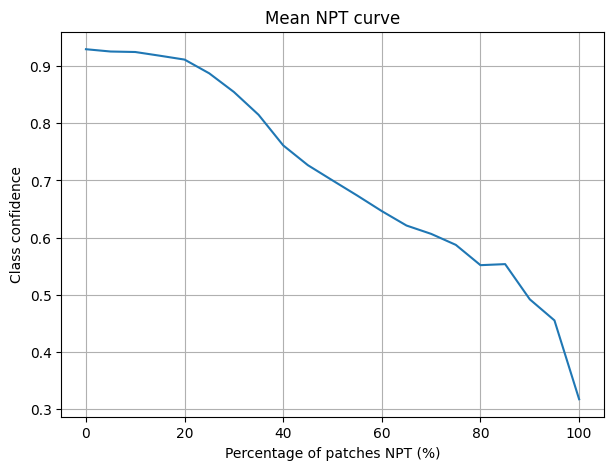

-----------------------
-----------------------
-----------------------


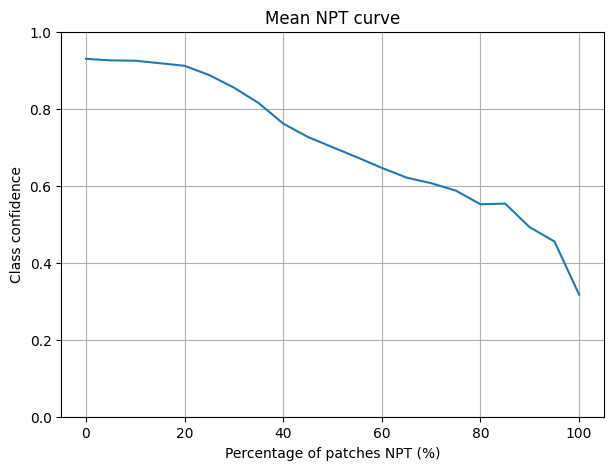

In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/negative/negative_curves/attention_rollout") 
curves = []
percentages = None

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    curves.append(data["confidences"])
    if percentages is None:
        percentages = data["percentages"]

curves = np.array(curves)
mean_conf = curves.mean(axis=0)

print("curves shape:", curves.shape)
print("percentages shape:", np.array(percentages).shape)


x_percent = np.array(percentages) * 100

plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches NPT (%)")
plt.ylabel("Class confidence")
plt.title("Mean NPT curve")
plt.grid(True)
plt.show()


print ("-----------------------")
print ("-----------------------")
print ("-----------------------")


plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches NPT (%)")
plt.ylim(0, 1)
plt.ylabel("Class confidence")
plt.title("Mean NPT curve")
plt.grid(True)
plt.show()




#### Each Class

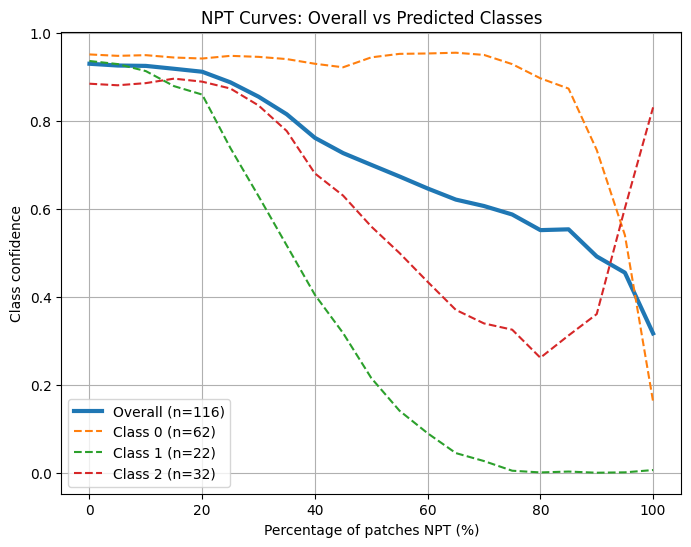

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/negative/negative_curves/attention_rollout")
csv_path = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/negative/negative_attention_rollout.csv")    

# Load CSV
df = pd.read_csv(csv_path)
uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

all_curves = []
class_curves = {}
percentages = None

# Load curves
for f in curve_dir.glob("*.npy"):
    uid = f.stem.replace("_curve", "")
    
    if uid not in uid_to_class:
        continue

    data = np.load(f, allow_pickle=True).item()
    confidences = data["confidences"]
    
    all_curves.append(confidences)
    
    cls = uid_to_class[uid]
    if cls not in class_curves:
        class_curves[cls] = []
    class_curves[cls].append(confidences)
    
    if percentages is None:
        percentages = data["percentages"]

# Safety check
if len(all_curves) == 0:
    raise ValueError("No matching curves found.")

# Convert to numpy
all_curves = np.array(all_curves)
overall_mean = all_curves.mean(axis=0)

# Plot
x_percent = np.array(percentages) * 100
plt.figure(figsize=(8, 6))

# Overall curve (thicker line)
plt.plot(
    x_percent,
    overall_mean,
    linewidth=3,
    label=f"Overall (n={len(all_curves)})"
)

# Per-class curves
for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linestyle="--",
        label=f"Class {cls} (n={len(curves)})"
    )

plt.xlabel("Percentage of patches NPT (%)")
plt.ylabel("Class confidence")
plt.title("NPT Curves: Overall vs Predicted Classes")
plt.legend()
plt.grid(True)
plt.show()


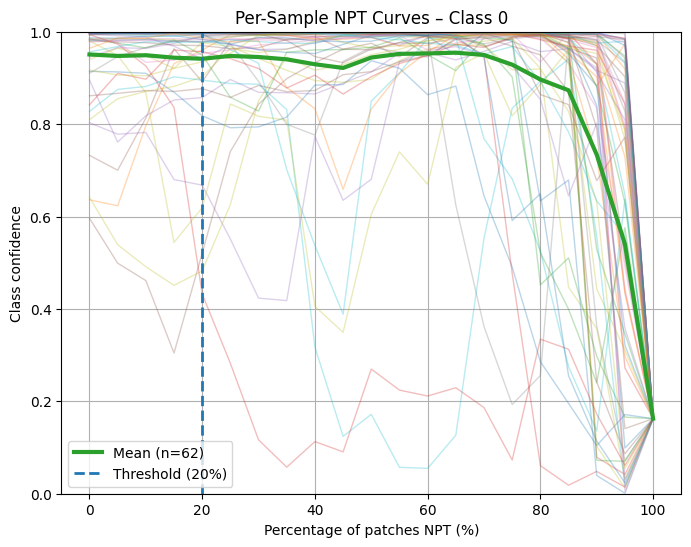

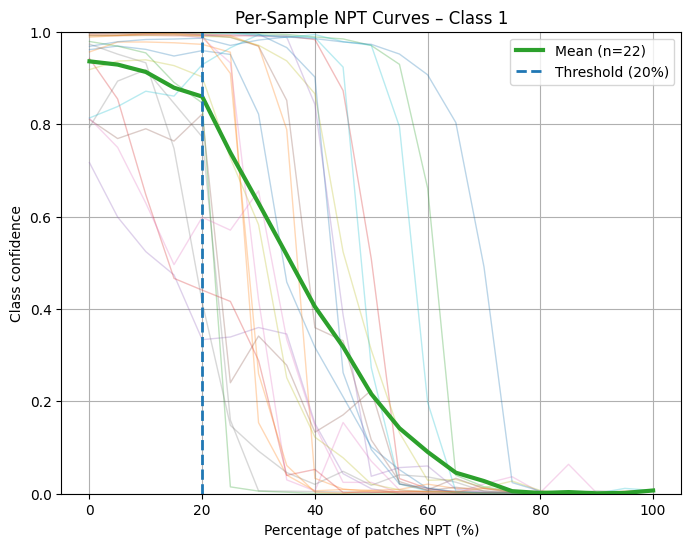

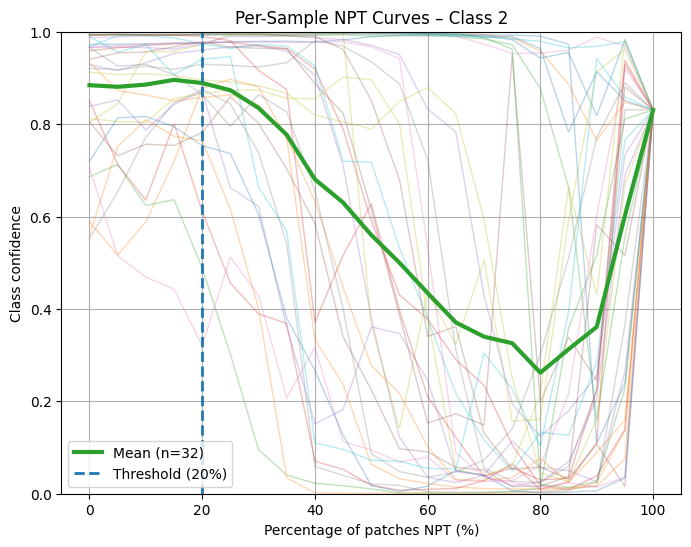

In [5]:
# --- Plot per-sample curves for every class ---

x_percent = np.array(percentages) * 100

for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)

    plt.figure(figsize=(8, 6))

    # Plot individual sample curves (light lines)
    for curve in curves:
        plt.plot(
            x_percent,
            curve,
            alpha=0.3,
            linewidth=1
        )

    # Plot mean curve (bold)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linewidth=3,
        label=f"Mean (n={len(curves)})"
    )

    # Vertical threshold at 20%
    plt.axvline(
        x=20,
        linestyle="--",
        linewidth=2,
        label="Threshold (20%)"
    )

    plt.xlabel("Percentage of patches NPT (%)")
    plt.ylabel("Class confidence")
    plt.title(f"Per-Sample NPT Curves – Class {cls}")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()
